In [2]:
import pandas as pd

import subfield_tree as sft
import w1_tree as wt
import geotopics_plots as gtp

In [3]:
PATH = "../data_clean/"

# subfield tree structure
df_subfield = (
    pd.read_csv(PATH+"df_topics.csv")
    [["domain_id", "field_id", "subfield_id", "domain_name", "field_name", "subfield_name"]]
    .drop_duplicates()
)
subfield_tree = sft.SubfieldTree(df_subfield)

# country

df_country = pd.read_csv(PATH+"raw/Floriana_country_info.csv")

# country-subfield dataframe (columns -- subfield_id as int)
df_cs = pd.read_csv(PATH+"df_country_subfield_roll_5y.csv", index_col=[0, 1, 2]).xs("individual", level=2).dropna(how="all")
df_cs.columns = df_cs.columns.astype(int)

In [4]:
w1_tree = wt.W1Tree(subfield_tree.df_subfield[["domain_id", "field_id", "subfield_id"]])

In [16]:
year = 2000

In [17]:
df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

df1 = df_prob.xs(year, level=1)
df2 = df_prob.xs(year, level=1)

In [18]:
# distance from country to country in 2023
w1_tree.dist(df1, df2)

second,AE,AL,AM,AR,AT,AU,AZ,BA,BB,BD,...,UG,US,UY,UZ,VE,VG,VN,ZA,ZM,ZW
first,,,,,,,,,,,,,,,,,,,,,
AE,0.000000,0.735198,0.687836,0.260434,0.169021,0.195885,0.517315,0.884869,0.814869,0.215854,...,0.347136,0.178269,0.252270,0.583592,0.266186,0.710877,0.499756,0.248644,0.628702,0.378684
AL,0.735198,0.000000,0.123962,0.585449,0.604923,0.687591,0.414414,1.000000,1.000000,0.692634,...,1.000000,0.663019,0.755688,0.217699,0.705294,0.080610,0.285012,0.710951,1.000000,0.878661
AM,0.687836,0.123962,0.000000,0.531929,0.549311,0.643432,0.356412,1.000000,0.975137,0.642553,...,0.975137,0.612583,0.709244,0.121678,0.655892,0.097188,0.231499,0.668428,1.000000,0.854147
AR,0.260434,0.585449,0.531929,0.000000,0.152778,0.187869,0.352843,0.842954,0.786414,0.136555,...,0.528971,0.149377,0.213949,0.427744,0.151055,0.571018,0.356835,0.208376,0.858162,0.387807
AT,0.169021,0.604923,0.549311,0.152778,0.000000,0.137921,0.445807,0.878826,0.864132,0.206899,...,0.457742,0.103758,0.289849,0.450464,0.263420,0.587734,0.373211,0.217012,0.721086,0.404130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VG,0.710877,0.080610,0.097188,0.571018,0.587734,0.675207,0.374054,1.000000,1.000000,0.674404,...,1.000000,0.647111,0.751616,0.183945,0.692884,0.000000,0.245591,0.700026,1.000000,0.875180
VN,0.499756,0.285012,0.231499,0.356835,0.373211,0.458879,0.313391,0.926290,0.944717,0.460187,...,0.797215,0.431333,0.530496,0.185013,0.480975,0.245591,0.000000,0.486613,0.934459,0.669857
ZA,0.248644,0.710951,0.668428,0.208376,0.217012,0.083177,0.546968,0.703593,0.849358,0.120648,...,0.341667,0.130118,0.122470,0.566748,0.079511,0.700026,0.486613,0.000000,0.807450,0.211689


In [19]:
c1 = "RU"
c2 = "FR"

In [20]:
df_c1 = df_prob.xs((year), level=(1))[subfield_tree.ordered_subfield_ids].loc[c1]
df_c2 = df_prob.xs((year), level=(1))[subfield_tree.ordered_subfield_ids].loc[c2]

c1_name = df_country[df_country["alpha-2"] == c1].name.iloc[0]
c2_name = df_country[df_country["alpha-2"] == c2].name.iloc[0]

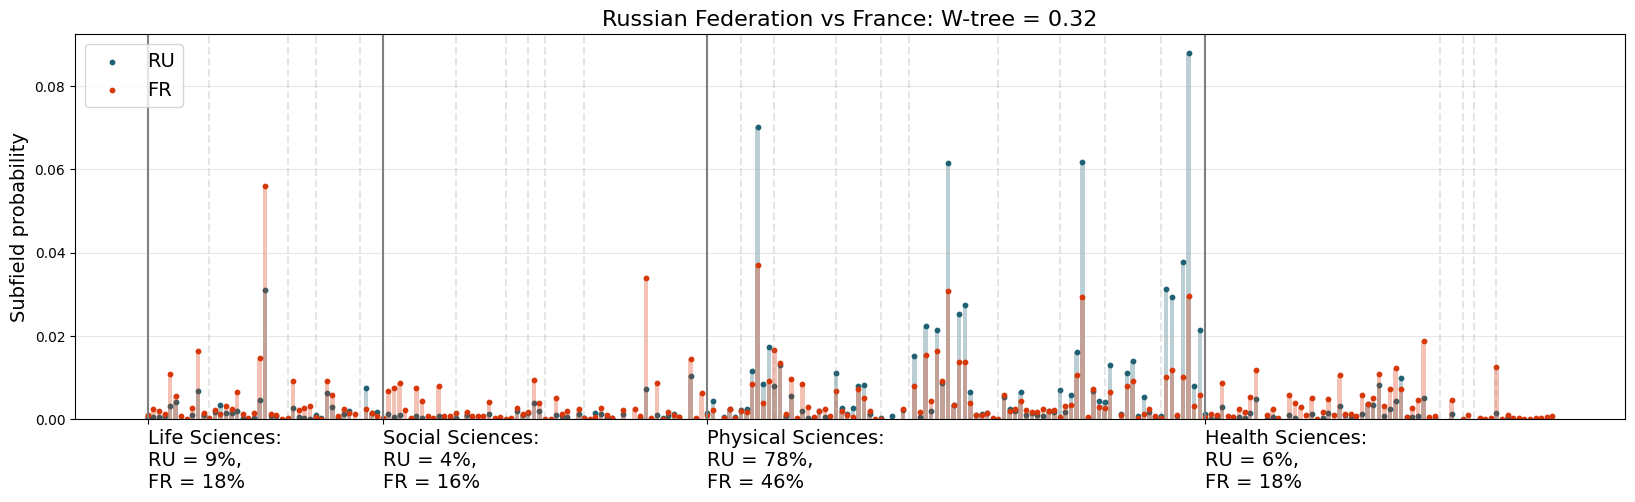

In [21]:
gtp.plot_two_profiles(df_c1, df_c2, subfield_tree, w1_tree, labels=[c1, c2], title="Tree-Wasserstein distance", names=[c1_name, c2_name])

/Users/irinavorobeva/Sociology/Geography Topics/geoTopics/irina_clean/geotopics_plots.py:101: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_profile


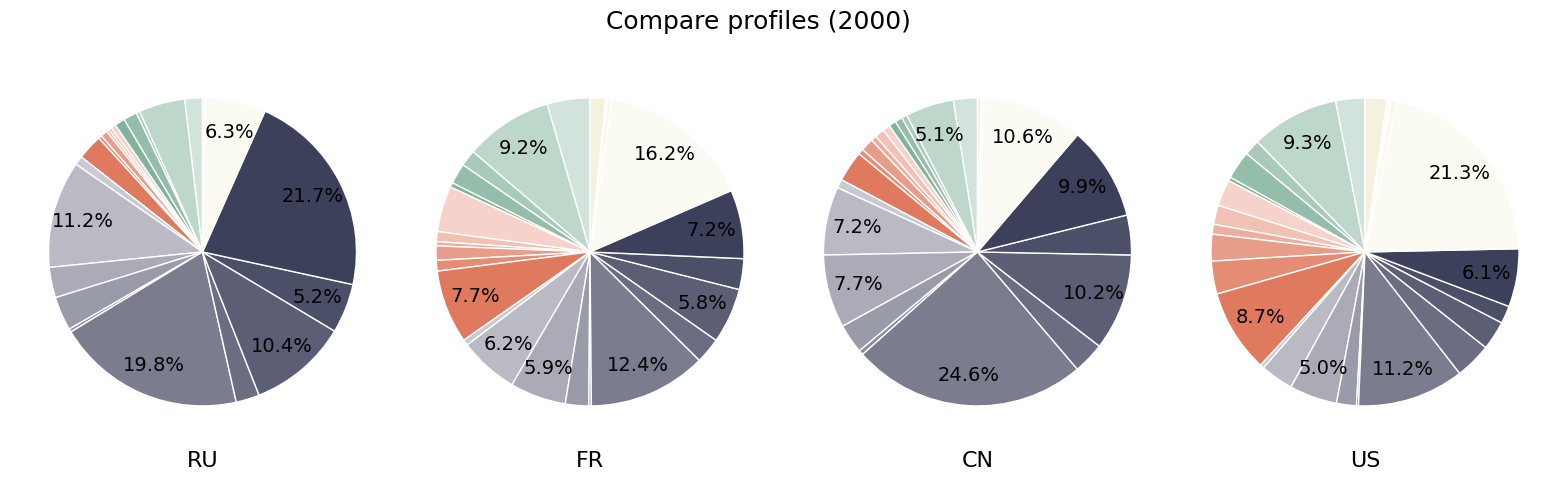

In [22]:
gtp.plot_profile_pie_fields(df_prob.xs((year), level=(1)), [c1, c2, "CN", "US"], subfield_tree, title=f"Compare profiles ({year})")